# 10 — Error Analysis and Feature Importance

## Objective

Interpret the final held-out December forecast produced by the frozen
tuned XGBoost model.

This notebook does not perform additional model selection or tuning.

The objectives are to:

- characterize the distribution of forecasting errors;
- identify operating conditions associated with larger errors;
- investigate rapid load transitions as a potential failure mode;
- inspect which features the final XGBoost model relies on most;
- translate model performance into engineering conclusions.

The final model configuration and December predictions remain frozen.

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.inspection import permutation_importance

from xgboost import XGBRegressor

In [3]:
#load predictions
predictions = pd.read_csv(
    "09_final_test_predictions.csv",
    parse_dates=["timestamp"]
)

predictions.head()

,timestamp,actual,xgboost_prediction,persistence_prediction,xgboost_error,absolute_error
0,2018-12-01 00:00:00,3.35,4.081170,3.82,-0.731170,0.731170
1,2018-12-01 00:15:00,3.89,3.632154,3.35,0.257846,0.257846
2,2018-12-01 00:30:00,3.85,4.085197,3.89,-0.235197,0.235197
3,2018-12-01 00:45:00,3.89,4.085197,3.85,-0.195197,0.195197
4,2018-12-01 01:00:00,3.89,3.799155,3.89,0.090845,0.090845


In [4]:
#Verification
print(
    "Rows:",
    len(predictions)
)

print(
    "Start:",
    predictions["timestamp"].min()
)

print(
    "End:",
    predictions["timestamp"].max()
)

predictions.isna().sum()

Rows: 2976
Start: 2018-12-01 00:00:00
End: 2018-12-31 23:45:00


timestamp                 0
actual                    0
xgboost_prediction        0
persistence_prediction    0
xgboost_error             0
absolute_error            0
dtype: int64

In [6]:
#Loading december operational context
con = duckdb.connect(
    "Steel_energy.duckdb"
)

december_context = con.sql("""
SELECT
    timestamp,
    hour,
    month,
    day_of_week,
    week_status,
    load_type,
    usage_15min_ago,
    usage_1h_ago,
    usage_lag_96,
    avg_usage_previous_hour
FROM gold_energy_features
WHERE timestamp >= '2018-12-01'
ORDER BY timestamp
""").df()

december_context.head()

,timestamp,hour,month,day_of_week,week_status,load_type,usage_15min_ago,usage_1h_ago,usage_lag_96,avg_usage_previous_hour
0,2018-12-01 00:00:00,0,12,Saturday,Weekend,Light_Load,3.82,3.92,3.96,3.8875
1,2018-12-01 00:15:00,0,12,Saturday,Weekend,Light_Load,3.35,3.92,4.07,3.7450
2,2018-12-01 00:30:00,0,12,Saturday,Weekend,Light_Load,3.89,3.89,4.00,3.7375
3,2018-12-01 00:45:00,0,12,Saturday,Weekend,Light_Load,3.85,3.82,4.00,3.7275
4,2018-12-01 01:00:00,1,12,Saturday,Weekend,Light_Load,3.89,3.35,4.00,3.7450


In [7]:
#Merging predictions with operating context
analysis_df = predictions.merge(
    december_context,
    on="timestamp",
    how="left",
    validate="one_to_one"
)

analysis_df = analysis_df.sort_values(
    "timestamp"
).reset_index(drop=True)

analysis_df.head()

,timestamp,actual,xgboost_prediction,persistence_prediction,xgboost_error,absolute_error,hour,month,day_of_week,week_status,load_type,usage_15min_ago,usage_1h_ago,usage_lag_96,avg_usage_previous_hour
0,2018-12-01 00:00:00,3.35,4.081170,3.82,-0.731170,0.731170,0,12,Saturday,Weekend,Light_Load,3.82,3.92,3.96,3.8875
1,2018-12-01 00:15:00,3.89,3.632154,3.35,0.257846,0.257846,0,12,Saturday,Weekend,Light_Load,3.35,3.92,4.07,3.7450
2,2018-12-01 00:30:00,3.85,4.085197,3.89,-0.235197,0.235197,0,12,Saturday,Weekend,Light_Load,3.89,3.89,4.00,3.7375
3,2018-12-01 00:45:00,3.89,4.085197,3.85,-0.195197,0.195197,0,12,Saturday,Weekend,Light_Load,3.85,3.82,4.00,3.7275
4,2018-12-01 01:00:00,3.89,3.799155,3.89,0.090845,0.090845,1,12,Saturday,Weekend,Light_Load,3.89,3.35,4.00,3.7450


In [8]:
#Verifying the merge
print(
    "Rows after merge:",
    len(analysis_df)
)

analysis_df.isna().sum()

Rows after merge: 2976


timestamp                  0
actual                     0
xgboost_prediction         0
persistence_prediction     0
xgboost_error              0
absolute_error             0
hour                       0
month                      0
day_of_week                0
week_status                0
load_type                  0
usage_15min_ago            0
usage_1h_ago               0
usage_lag_96               0
avg_usage_previous_hour    0
dtype: int64

In [9]:
#Adding useful error variables
analysis_df[
    "error_direction"
] = np.where(
    analysis_df["xgboost_error"] > 0,
    "Underprediction",
    "Overprediction"
)

analysis_df[
    "squared_error"
] = (
    analysis_df["xgboost_error"] ** 2
)

analysis_df.head()

,timestamp,actual,xgboost_prediction,persistence_prediction,xgboost_error,absolute_error,hour,month,day_of_week,week_status,load_type,usage_15min_ago,usage_1h_ago,usage_lag_96,avg_usage_previous_hour,error_direction,squared_error
0,2018-12-01 00:00:00,3.35,4.081170,3.82,-0.731170,0.731170,0,12,Saturday,Weekend,Light_Load,3.82,3.92,3.96,3.8875,Overprediction,0.534609
1,2018-12-01 00:15:00,3.89,3.632154,3.35,0.257846,0.257846,0,12,Saturday,Weekend,Light_Load,3.35,3.92,4.07,3.7450,Underprediction,0.066484
2,2018-12-01 00:30:00,3.85,4.085197,3.89,-0.235197,0.235197,0,12,Saturday,Weekend,Light_Load,3.89,3.89,4.00,3.7375,Overprediction,0.055318
3,2018-12-01 00:45:00,3.89,4.085197,3.85,-0.195197,0.195197,0,12,Saturday,Weekend,Light_Load,3.85,3.82,4.00,3.7275,Overprediction,0.038102
4,2018-12-01 01:00:00,3.89,3.799155,3.89,0.090845,0.090845,1,12,Saturday,Weekend,Light_Load,3.89,3.35,4.00,3.7450,Underprediction,0.008253


In [10]:
#Overall error statistics
error_summary = pd.Series({
    "Mean signed error":
        analysis_df["xgboost_error"].mean(),

    "Median signed error":
        analysis_df["xgboost_error"].median(),

    "MAE":
        analysis_df["absolute_error"].mean(),

    "Median absolute error":
        analysis_df["absolute_error"].median(),

    "90th percentile absolute error":
        analysis_df["absolute_error"].quantile(0.90),

    "95th percentile absolute error":
        analysis_df["absolute_error"].quantile(0.95),

    "Maximum absolute error":
        analysis_df["absolute_error"].max()
})

error_summary

Mean signed error                 -0.474186
Median signed error               -0.224700
MAE                                3.236550
Median absolute error              0.618962
90th percentile absolute error    10.288855
95th percentile absolute error    15.302187
Maximum absolute error            60.293098
dtype: float64

In [11]:
#Percentage of forecasts within useful error bands
within_2 = (
    analysis_df["absolute_error"] <= 2
).mean() * 100

within_5 = (
    analysis_df["absolute_error"] <= 5
).mean() * 100

within_10 = (
    analysis_df["absolute_error"] <= 10
).mean() * 100

print(
    f"Forecasts within ±2 kWh: "
    f"{within_2:.1f}%"
)

print(
    f"Forecasts within ±5 kWh: "
    f"{within_5:.1f}%"
)

print(
    f"Forecasts within ±10 kWh: "
    f"{within_10:.1f}%"
)

Forecasts within ±2 kWh: 69.3%
Forecasts within ±5 kWh: 80.3%
Forecasts within ±10 kWh: 89.7%


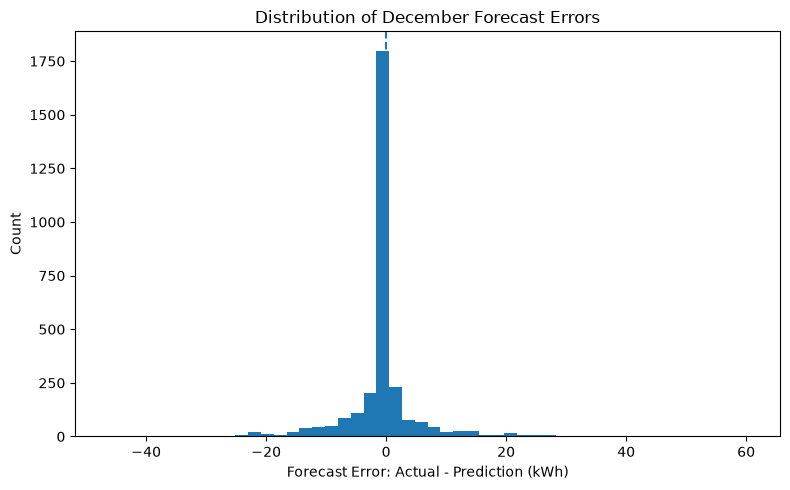

In [12]:
#Signed error distribution
plt.figure(
    figsize=(8, 5)
)

plt.hist(
    analysis_df["xgboost_error"],
    bins=50
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Forecast Error: Actual - Prediction (kWh)"
)

plt.ylabel(
    "Count"
)

plt.title(
    "Distribution of December Forecast Errors"
)

plt.tight_layout()

plt.show()

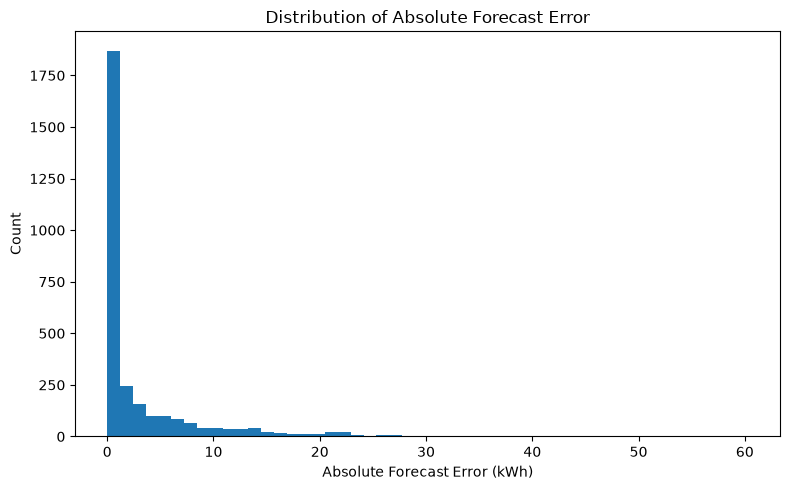

In [13]:
#Absolute error distribution
plt.figure(
    figsize=(8, 5)
)

plt.hist(
    analysis_df["absolute_error"],
    bins=50
)

plt.xlabel(
    "Absolute Forecast Error (kWh)"
)

plt.ylabel(
    "Count"
)

plt.title(
    "Distribution of Absolute Forecast Error"
)

plt.tight_layout()

plt.show()

In [14]:
#Underprediction vs overprediction
direction_summary = (
    analysis_df
    .groupby(
        "error_direction"
    )
    .agg(
        count=(
            "absolute_error",
            "size"
        ),
        mean_absolute_error=(
            "absolute_error",
            "mean"
        )
    )
)

direction_summary[
    "percentage"
] = (
    direction_summary["count"]
    /
    len(analysis_df)
    *
    100
)

direction_summary

,count,mean_absolute_error,percentage
error_direction,,,
Overprediction,1979,2.790084,66.498656
Underprediction,997,4.122766,33.501344


In [15]:
#MAE by hour of dat
hourly_error = (
    analysis_df
    .groupby(
        "hour"
    )
    .agg(
        MAE=(
            "absolute_error",
            "mean"
        ),
        mean_error=(
            "xgboost_error",
            "mean"
        ),
        observations=(
            "absolute_error",
            "size"
        )
    )
    .reset_index()
)

hourly_error

,hour,MAE,mean_error,observations
0,0,0.880521,-0.751422,124
1,1,0.390993,-0.229854,124
2,2,0.343140,-0.178009,124
3,3,0.395250,-0.271870,124
4,4,0.301731,-0.129875,124
5,5,0.382131,-0.235540,124
6,6,0.327087,-0.104351,124
7,7,0.546608,-0.100590,124
8,8,8.302056,-3.153686,124
9,9,5.930909,0.021252,124


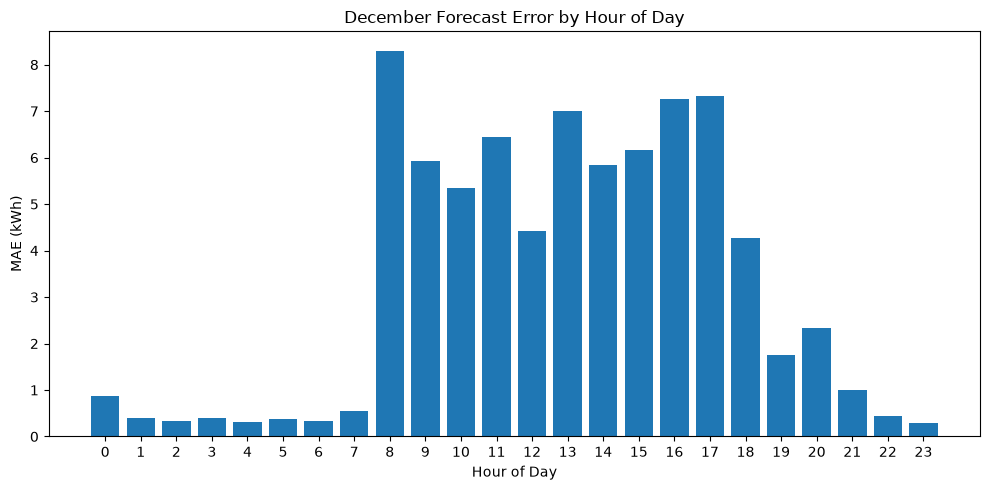

In [16]:
#Plot MAE by hour
plt.figure(
    figsize=(10, 5)
)

plt.bar(
    hourly_error["hour"],
    hourly_error["MAE"]
)

plt.xlabel(
    "Hour of Day"
)

plt.ylabel(
    "MAE (kWh)"
)

plt.title(
    "December Forecast Error by Hour of Day"
)

plt.xticks(
    range(24)
)

plt.tight_layout()

plt.show()

In [17]:
#MAE by load type
load_type_error = (
    analysis_df
    .groupby(
        "load_type"
    )
    .agg(
        MAE=(
            "absolute_error",
            "mean"
        ),
        mean_error=(
            "xgboost_error",
            "mean"
        ),
        observations=(
            "absolute_error",
            "size"
        )
    )
    .sort_values(
        "MAE",
        ascending=False
    )
)

load_type_error

,MAE,mean_error,observations
load_type,,,
Medium_Load,6.495541,0.505612,704
Maximum_Load,5.328455,-1.297110,528
Light_Load,1.287666,-0.620559,1744


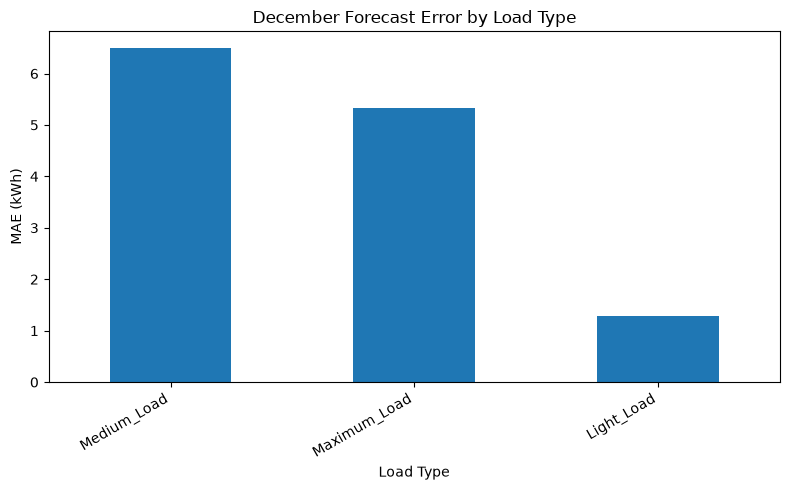

In [18]:
#MAE by load type plot
load_type_error[
    "MAE"
].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.ylabel(
    "MAE (kWh)"
)

plt.xlabel(
    "Load Type"
)

plt.title(
    "December Forecast Error by Load Type"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.show()

In [19]:
#Weekday vs weekend
week_status_error = (
    analysis_df
    .groupby(
        "week_status"
    )
    .agg(
        MAE=(
            "absolute_error",
            "mean"
        ),
        mean_error=(
            "xgboost_error",
            "mean"
        ),
        observations=(
            "absolute_error",
            "size"
        )
    )
)

week_status_error

,MAE,mean_error,observations
week_status,,,
Weekday,4.05186,-0.423501,2016
Weekend,1.52440,-0.580625,960


In [20]:
#Error by day of week
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_error = (
    analysis_df
    .groupby(
        "day_of_week"
    )
    .agg(
        MAE=(
            "absolute_error",
            "mean"
        ),
        mean_error=(
            "xgboost_error",
            "mean"
        )
    )
    .reindex(
        day_order
    )
)

day_error

,MAE,mean_error
day_of_week,,
Monday,3.288217,-1.062762
Tuesday,3.829712,-0.592482
Wednesday,4.998956,0.582579
Thursday,4.039168,-0.816475
Friday,4.294158,-0.068552
Saturday,1.800567,-1.232206
Sunday,1.248232,0.070956


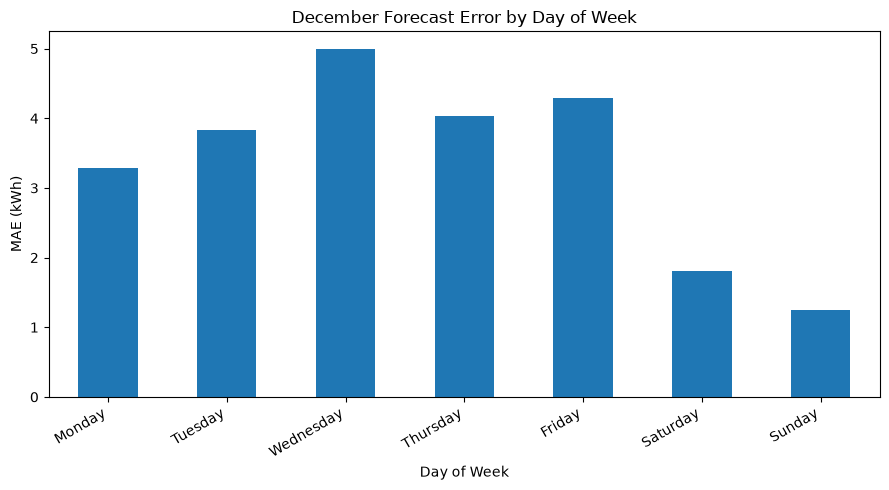

In [21]:
#Plot error by day
day_error[
    "MAE"
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.ylabel(
    "MAE (kWh)"
)

plt.xlabel(
    "Day of Week"
)

plt.title(
    "December Forecast Error by Day of Week"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.show()

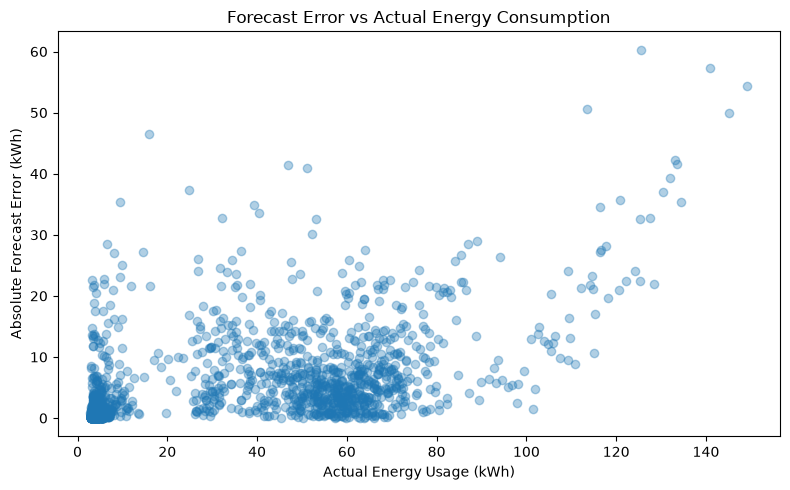

In [22]:
#Error vs actual consumption
plt.figure(
    figsize=(8, 5)
)

plt.scatter(
    analysis_df["actual"],
    analysis_df["absolute_error"],
    alpha=0.35
)

plt.xlabel(
    "Actual Energy Usage (kWh)"
)

plt.ylabel(
    "Absolute Forecast Error (kWh)"
)

plt.title(
    "Forecast Error vs Actual Energy Consumption"
)

plt.tight_layout()

plt.show()

In [23]:
#Divide consumption into quartiles
analysis_df[
    "usage_quartile"
] = pd.qcut(
    analysis_df["actual"],
    q=4,
    duplicates="drop"
)

usage_error = (
    analysis_df
    .groupby(
        "usage_quartile",
        observed=True
    )
    .agg(
        mean_usage=(
            "actual",
            "mean"
        ),
        MAE=(
            "absolute_error",
            "mean"
        ),
        observations=(
            "absolute_error",
            "size"
        )
    )
)

usage_error

,mean_usage,MAE,observations
usage_quartile,,,
"(2.879, 3.64]",3.352103,0.762685,756
"(3.64, 4.21]",3.964853,0.653224,750
"(4.21, 37.022]",9.650138,3.154674,726
"(37.022, 149.18]",63.068481,8.434371,744


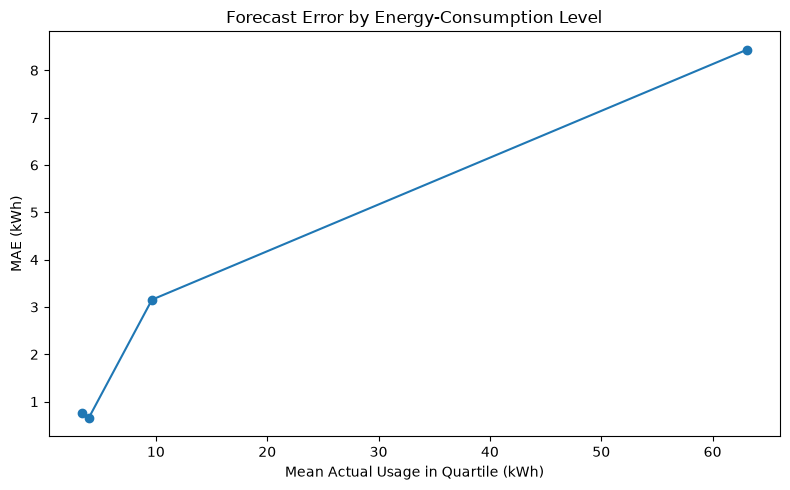

In [24]:
#plot error by consumption level
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    usage_error["mean_usage"],
    usage_error["MAE"],
    marker="o"
)

plt.xlabel(
    "Mean Actual Usage in Quartile (kWh)"
)

plt.ylabel(
    "MAE (kWh)"
)

plt.title(
    "Forecast Error by Energy-Consumption Level"
)

plt.tight_layout()

plt.show()

In [25]:
#Largest individual errors
largest_errors = (
    analysis_df[
        [
            "timestamp",
            "actual",
            "xgboost_prediction",
            "xgboost_error",
            "absolute_error",
            "load_type",
            "hour",
            "day_of_week"
        ]
    ]
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(20)
)

largest_errors

,timestamp,actual,xgboost_prediction,xgboost_error,absolute_error,load_type,hour,day_of_week
1796,2018-12-19 17:00:00,125.50,65.206900,60.293098,60.293098,Medium_Load,17,Wednesday
1773,2018-12-19 11:15:00,140.80,83.481010,57.318990,57.318990,Maximum_Load,11,Wednesday
1785,2018-12-19 14:15:00,149.18,94.827290,54.352707,54.352707,Medium_Load,14,Wednesday
1690,2018-12-18 14:30:00,113.51,62.995544,50.514456,50.514456,Medium_Load,14,Tuesday
1788,2018-12-19 15:00:00,145.22,95.268170,49.951827,49.951827,Medium_Load,15,Wednesday
1704,2018-12-18 18:00:00,15.95,62.432360,-46.482362,46.482362,Maximum_Load,18,Tuesday
1315,2018-12-14 16:45:00,133.20,90.903900,42.296100,42.296100,Medium_Load,16,Friday
1793,2018-12-19 16:15:00,133.56,91.972250,41.587748,41.587748,Medium_Load,16,Wednesday
1571,2018-12-17 08:45:00,46.94,88.371120,-41.431117,41.431117,Light_Load,8,Monday
2436,2018-12-26 09:00:00,51.08,92.045260,-40.965258,40.965258,Light_Load,9,Wednesday


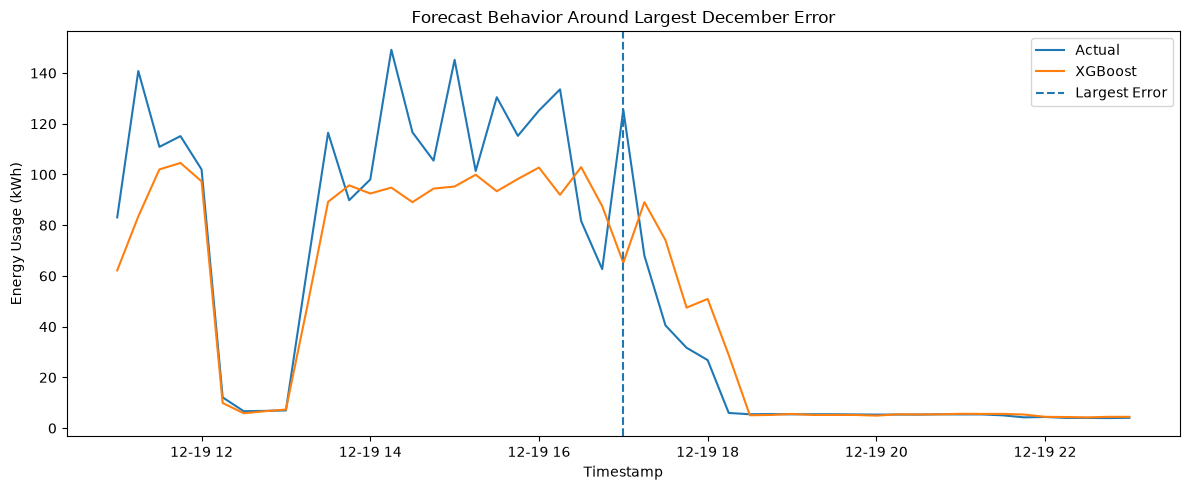

In [26]:
#plot actual vs prediction around the largest error
worst_timestamp = (
    largest_errors
    .iloc[0]["timestamp"]
)

window_start = (
    worst_timestamp
    -
    pd.Timedelta(
        hours=6
    )
)

window_end = (
    worst_timestamp
    +
    pd.Timedelta(
        hours=6
    )
)

worst_window = analysis_df[
    (
        analysis_df["timestamp"]
        >= window_start
    )
    &
    (
        analysis_df["timestamp"]
        <= window_end
    )
]

plt.figure(
    figsize=(12, 5)
)

plt.plot(
    worst_window["timestamp"],
    worst_window["actual"],
    label="Actual"
)

plt.plot(
    worst_window["timestamp"],
    worst_window["xgboost_prediction"],
    label="XGBoost"
)

plt.axvline(
    worst_timestamp,
    linestyle="--",
    label="Largest Error"
)

plt.xlabel(
    "Timestamp"
)

plt.ylabel(
    "Energy Usage (kWh)"
)

plt.title(
    "Forecast Behavior Around Largest December Error"
)

plt.legend()

plt.tight_layout()

plt.show()

In [27]:
#calculate 15 min load transitions
analysis_df[
    "transition"
] = (
    analysis_df["actual"]
    -
    analysis_df["persistence_prediction"]
)

analysis_df[
    "transition_magnitude"
] = (
    analysis_df["transition"].abs()
)

analysis_df[
    [
        "timestamp",
        "actual",
        "persistence_prediction",
        "transition",
        "transition_magnitude",
        "absolute_error"
    ]
].head()

,timestamp,actual,persistence_prediction,transition,transition_magnitude,absolute_error
0,2018-12-01 00:00:00,3.35,3.82,-0.47,0.47,0.731170
1,2018-12-01 00:15:00,3.89,3.35,0.54,0.54,0.257846
2,2018-12-01 00:30:00,3.85,3.89,-0.04,0.04,0.235197
3,2018-12-01 00:45:00,3.89,3.85,0.04,0.04,0.195197
4,2018-12-01 01:00:00,3.89,3.89,0.00,0.00,0.090845


In [28]:
#transition/error correlation
transition_correlation = (
    analysis_df[
        [
            "transition_magnitude",
            "absolute_error"
        ]
    ]
    .corr()
    .iloc[0, 1]
)

print(
    f"Correlation between transition magnitude "
    f"and absolute forecast error: "
    f"{transition_correlation:.3f}"
)

Correlation between transition magnitude and absolute forecast error: 0.693


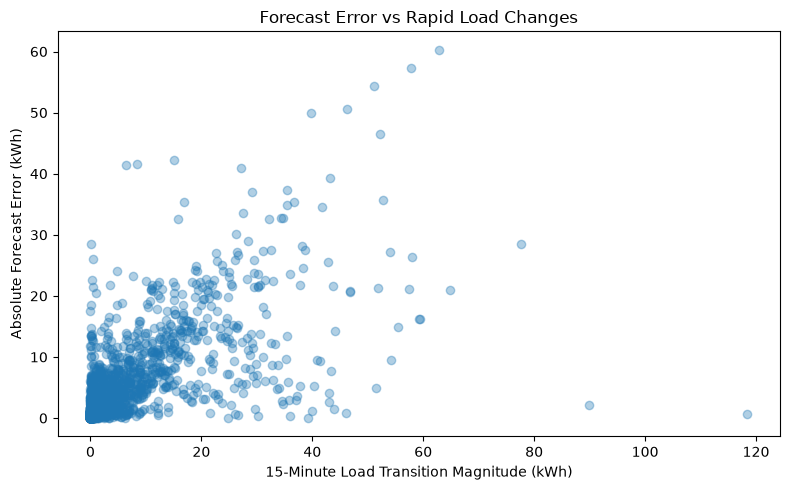

In [29]:
#Scatter transition magnitude vs error
plt.figure(
    figsize=(8, 5)
)

plt.scatter(
    analysis_df["transition_magnitude"],
    analysis_df["absolute_error"],
    alpha=0.35
)

plt.xlabel(
    "15-Minute Load Transition Magnitude (kWh)"
)

plt.ylabel(
    "Absolute Forecast Error (kWh)"
)

plt.title(
    "Forecast Error vs Rapid Load Changes"
)

plt.tight_layout()

plt.show()

In [30]:
#Define extrme transitions
transition_threshold = (
    analysis_df[
        "transition_magnitude"
    ]
    .quantile(
        0.90
    )
)

print(
    f"90th percentile transition magnitude: "
    f"{transition_threshold:.2f} kWh"
)

90th percentile transition magnitude: 12.84 kWh


In [31]:
#Compare ordinary periods vs rapid transitions
analysis_df[
    "transition_group"
] = np.where(
    analysis_df[
        "transition_magnitude"
    ]
    >= transition_threshold,

    "Top 10% transitions",

    "Other 90%"
)

transition_group_error = (
    analysis_df
    .groupby(
        "transition_group"
    )
    .agg(
        MAE=(
            "absolute_error",
            "mean"
        ),
        RMSE=(
            "squared_error",
            lambda x:
                np.sqrt(
                    x.mean()
                )
        ),
        observations=(
            "absolute_error",
            "size"
        )
    )
)

transition_group_error

,MAE,RMSE,observations
transition_group,,,
Other 90%,1.938307,4.040227,2678
Top 10% transitions,14.903317,18.102354,298


In [32]:
#Transition magnitude deciles
analysis_df[
    "transition_decile"
] = pd.qcut(
    analysis_df[
        "transition_magnitude"
    ],
    q=10,
    duplicates="drop"
)

transition_deciles = (
    analysis_df
    .groupby(
        "transition_decile",
        observed=True
    )
    .agg(
        mean_transition=(
            "transition_magnitude",
            "mean"
        ),
        MAE=(
            "absolute_error",
            "mean"
        )
    )
)

transition_deciles

,mean_transition,MAE
transition_decile,,
"(-0.001, 0.04]",0.022442,0.570189
"(0.04, 0.07]",0.069712,0.766895
"(0.07, 0.11]",0.084983,0.577804
"(0.11, 0.29]",0.192624,1.232222
"(0.29, 0.61]",0.453488,1.295340
"(0.61, 1.11]",0.800277,1.452841
"(1.11, 4.6]",2.580936,3.767889
"(4.6, 12.835]",8.147162,7.453537
"(12.835, 118.4]",25.875403,14.903317


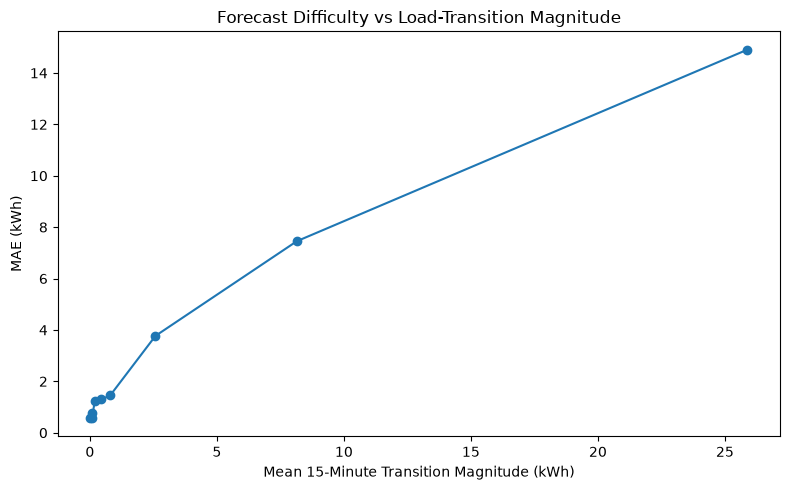

In [33]:
#Plot transition difficulty
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    transition_deciles[
        "mean_transition"
    ],
    transition_deciles[
        "MAE"
    ],
    marker="o"
)

plt.xlabel(
    "Mean 15-Minute Transition Magnitude (kWh)"
)

plt.ylabel(
    "MAE (kWh)"
)

plt.title(
    "Forecast Difficulty vs Load-Transition Magnitude"
)

plt.tight_layout()

plt.show()

#Feature importance analysis
# Feature Importance

The final model is reconstructed using exactly the feature set,
preprocessing pipeline, training period, and hyperparameters selected
before the December held-out evaluation.

The model is refitted only for interpretation.

No additional hyperparameter search, feature selection, or model
selection is performed.

In [34]:
#Load gold dataset

df = con.sql("""
SELECT *
FROM gold_energy_features
ORDER BY timestamp
""").df()

df = df.sort_values(
    "timestamp"
).reset_index(drop=True)

In [37]:
#Define same exact frozen feature set

numeric_features = [
    "usage_15min_ago",
    "usage_1h_ago",
    "usage_lag_96",
    "avg_usage_previous_hour",
    "hour",
    "month"
]

categorical_features = [
    "day_of_week",
    "week_status",
    "load_type"
]

feature_columns = (
    numeric_features
    +
    categorical_features
)

target = "usage_kwh"

In [38]:
#Recreate Jan-Nov training and december test
development_df = df[
    df["timestamp"]
    <
    "2018-12-01"
].copy()

test_df = df[
    df["timestamp"]
    >=
    "2018-12-01"
].copy()

train_df = development_df.dropna(
    subset=feature_columns + [target]
).copy()

final_test_df = test_df.dropna(
    subset=feature_columns + [target]
).copy()

print(
    len(train_df),
    len(final_test_df)
)

31968 2976


In [39]:
#Frozen preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

In [40]:
#Frozen hyperparameters
final_xgb_params = {
    "subsample": 0.85,
    "reg_lambda": 1,
    "reg_alpha": 1.0,
    "n_estimators": 600,
    "max_depth": 7,
    "learning_rate": 0.01,
    "colsample_bytree": 1.0
}

In [41]:
#Reconstruct exact final pipeline
final_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1,
            verbosity=0,
            **final_xgb_params
        )
    )
])

In [42]:
#Define train test metrics
X_train = train_df[
    feature_columns
]

y_train = train_df[
    target
]

X_test = final_test_df[
    feature_columns
]

y_test = final_test_df[
    target
]

In [43]:
#Fit frozen model
final_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['usage_15min_ago','usage_1h_ago','usage_lag_96',...,'day_of_week', 'week_status','load_type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. T

In [44]:
#Verify reconstructed predictions
reconstructed_predictions = (
    final_model.predict(
        X_test
    )
)

max_prediction_difference = (
    np.max(
        np.abs(
            reconstructed_predictions
            -
            predictions[
                "xgboost_prediction"
            ].values
        )
    )
)

print(
    "Maximum difference between "
    "Notebook 09 and reconstructed predictions:",
    max_prediction_difference
)

Maximum difference between Notebook 09 and reconstructed predictions: 3.808593746157385e-06


In [45]:
#Optional assertion
assert (
    max_prediction_difference
    <
    1e-5
)

print(
    "Final model successfully reproduced."
)

Final model successfully reproduced.


In [46]:
#Native XGBoost importance
#Get transformed feature names
transformed_feature_names = (
    final_model
    .named_steps[
        "preprocessor"
    ]
    .get_feature_names_out()
)

transformed_feature_names

array(['num__usage_15min_ago', 'num__usage_1h_ago', 'num__usage_lag_96',
       'num__avg_usage_previous_hour', 'num__hour', 'num__month',
       'cat__day_of_week_Friday', 'cat__day_of_week_Monday',
       'cat__day_of_week_Saturday', 'cat__day_of_week_Sunday',
       'cat__day_of_week_Thursday', 'cat__day_of_week_Tuesday',
       'cat__day_of_week_Wednesday', 'cat__week_status_Weekday',
       'cat__week_status_Weekend', 'cat__load_type_Light_Load',
       'cat__load_type_Maximum_Load', 'cat__load_type_Medium_Load'],
      dtype=object)

In [47]:
#Extract XGBoost importance
xgb_estimator = (
    final_model
    .named_steps[
        "model"
    ]
)

importance_df = pd.DataFrame({
    "feature":
        transformed_feature_names,

    "importance":
        xgb_estimator.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

importance_df

,feature,importance
0,num__usage_15min_ago,0.696130
1,cat__load_type_Maximum_Load,0.051786
2,cat__day_of_week_Monday,0.034900
3,cat__load_type_Medium_Load,0.033406
4,cat__week_status_Weekday,0.030690
5,num__hour,0.029839
6,num__avg_usage_previous_hour,0.020994
7,cat__day_of_week_Sunday,0.016360
8,num__usage_lag_96,0.014872
9,num__month,0.012430


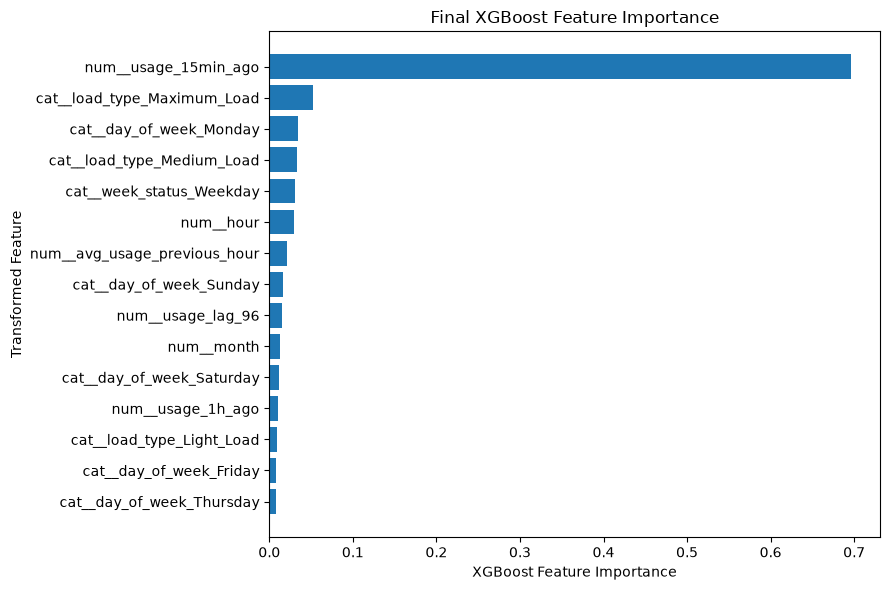

In [48]:
#Plot transformed feature importance
top_importance = (
    importance_df
    .head(15)
    .sort_values(
        "importance"
    )
)

plt.figure(
    figsize=(9, 6)
)

plt.barh(
    top_importance["feature"],
    top_importance["importance"]
)

plt.xlabel(
    "XGBoost Feature Importance"
)

plt.ylabel(
    "Transformed Feature"
)

plt.title(
    "Final XGBoost Feature Importance"
)

plt.tight_layout()

plt.show()

In [49]:
#Map transformed features back to original variablres
def get_original_feature(
    transformed_name
):

    clean_name = (
        transformed_name
        .replace(
            "num__",
            ""
        )
        .replace(
            "cat__",
            ""
        )
    )

    for feature in feature_columns:

        if (
            clean_name == feature
            or
            clean_name.startswith(
                feature + "_"
            )
        ):

            return feature

    return clean_name

In [50]:
#Create grouped feature importance
importance_df[
    "original_feature"
] = (
    importance_df[
        "feature"
    ]
    .apply(
        get_original_feature
    )
)

grouped_importance = (
    importance_df
    .groupby(
        "original_feature"
    )[
        "importance"
    ]
    .sum()
    .sort_values(
        ascending=False
    )
    .reset_index()
)

grouped_importance

,original_feature,importance
0,usage_15min_ago,0.696130
1,load_type,0.094155
2,day_of_week,0.090323
3,week_status,0.030690
4,hour,0.029839
5,avg_usage_previous_hour,0.020994
6,usage_lag_96,0.014872
7,month,0.012430
8,usage_1h_ago,0.010567


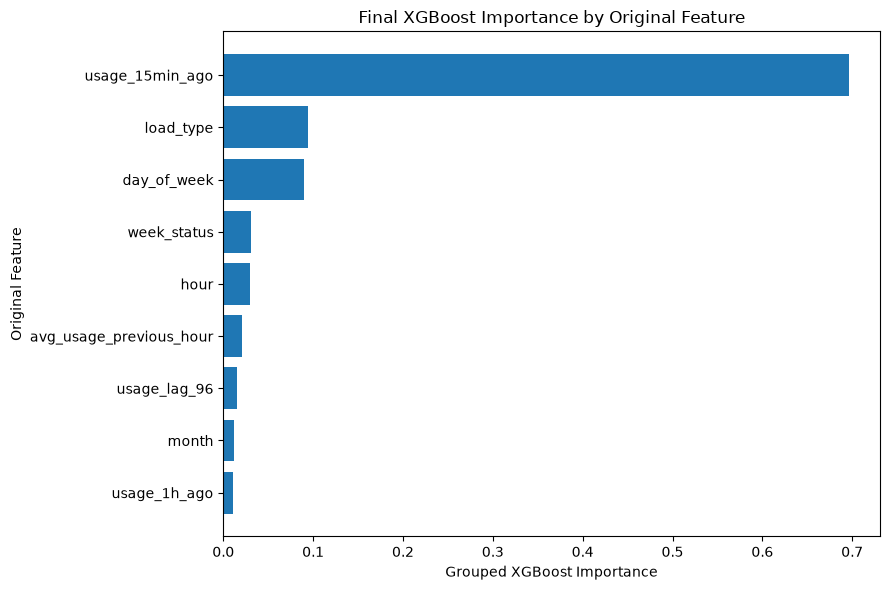

In [51]:
#Plot grouped XGBBoost importance
plot_importance = (
    grouped_importance
    .sort_values(
        "importance"
    )
)

plt.figure(
    figsize=(9, 6)
)

plt.barh(
    plot_importance[
        "original_feature"
    ],
    plot_importance[
        "importance"
    ]
)

plt.xlabel(
    "Grouped XGBoost Importance"
)

plt.ylabel(
    "Original Feature"
)

plt.title(
    "Final XGBoost Importance by Original Feature"
)

plt.tight_layout()

plt.show()

In [52]:
#Permutation importance
permutation_results = (
    permutation_importance(
        final_model,
        X_test,
        y_test,
        scoring="neg_mean_absolute_error",
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )
)

In [53]:
#Permutation importance table
permutation_df = pd.DataFrame({
    "feature":
        feature_columns,

    "MAE_increase_mean":
        permutation_results.importances_mean,

    "MAE_increase_std":
        permutation_results.importances_std
})

permutation_df = (
    permutation_df
    .sort_values(
        "MAE_increase_mean",
        ascending=False
    )
    .reset_index(drop=True)
)

permutation_df

,feature,MAE_increase_mean,MAE_increase_std
0,usage_15min_ago,23.148780,0.406148
1,avg_usage_previous_hour,5.332370,0.111850
2,hour,1.705773,0.066463
3,load_type,1.650973,0.092577
4,usage_1h_ago,1.542235,0.045101
5,usage_lag_96,1.095607,0.044487
6,week_status,0.117825,0.031365
7,day_of_week,0.060353,0.011733
8,month,0.000000,0.000000


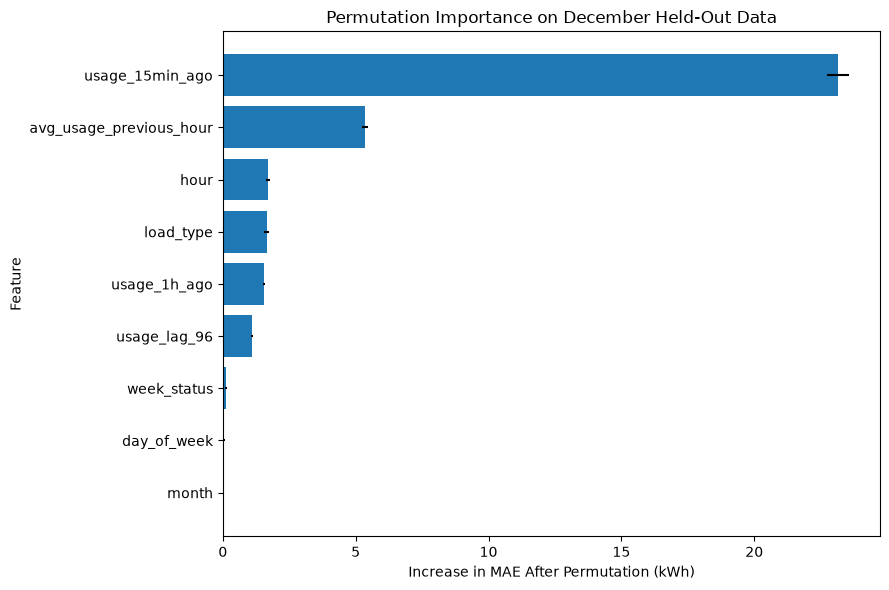

In [54]:
#Plot permuation importance
plot_perm = (
    permutation_df
    .sort_values(
        "MAE_increase_mean"
    )
)

plt.figure(
    figsize=(9, 6)
)

plt.barh(
    plot_perm["feature"],
    plot_perm["MAE_increase_mean"],
    xerr=plot_perm["MAE_increase_std"]
)

plt.xlabel(
    "Increase in MAE After Permutation (kWh)"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Permutation Importance on December Held-Out Data"
)

plt.tight_layout()

plt.show()

In [55]:
#Compare both importance methods
importance_comparison = (
    grouped_importance
    .rename(
        columns={
            "original_feature":
                "feature",

            "importance":
                "XGBoost_importance"
        }
    )
    .merge(
        permutation_df[
            [
                "feature",
                "MAE_increase_mean"
            ]
        ],
        on="feature",
        how="left"
    )
)

importance_comparison = (
    importance_comparison
    .sort_values(
        "MAE_increase_mean",
        ascending=False
    )
)

importance_comparison

,feature,XGBoost_importance,MAE_increase_mean
0,usage_15min_ago,0.696130,23.148780
5,avg_usage_previous_hour,0.020994,5.332370
4,hour,0.029839,1.705773
1,load_type,0.094155,1.650973
8,usage_1h_ago,0.010567,1.542235
6,usage_lag_96,0.014872,1.095607
3,week_status,0.030690,0.117825
2,day_of_week,0.090323,0.060353
7,month,0.012430,0.000000


In [56]:
#Save complete error analysis dataset
analysis_df.to_csv(
    "10_error_analysis.csv",
    index=False
)

print(
    "Saved: 10_error_analysis.csv"
)

Saved: 10_error_analysis.csv


In [57]:
#Save feature importance tables
grouped_importance.to_csv(
    "10_xgboost_feature_importance.csv",
    index=False
)

permutation_df.to_csv(
    "10_permutation_importance.csv",
    index=False
)

print(
    "Feature importance tables saved."
)

Feature importance tables saved.


In [58]:
#Print key info for conclusions
print(
    "ERROR ANALYSIS SUMMARY"
)

print(
    "----------------------"
)

print(
    f"Mean signed error: "
    f"{analysis_df['xgboost_error'].mean():.3f} kWh"
)

print(
    f"Median absolute error: "
    f"{analysis_df['absolute_error'].median():.3f} kWh"
)

print(
    f"90th percentile absolute error: "
    f"{analysis_df['absolute_error'].quantile(0.90):.3f} kWh"
)

print(
    f"95th percentile absolute error: "
    f"{analysis_df['absolute_error'].quantile(0.95):.3f} kWh"
)

print()

print(
    f"Transition/error correlation: "
    f"{transition_correlation:.3f}"
)

print()

print(
    "MAE BY TRANSITION GROUP"
)

print(
    transition_group_error
)

print()

print(
    "TOP PERMUTATION FEATURES"
)

print(
    permutation_df.head(5)
)

ERROR ANALYSIS SUMMARY
----------------------
Mean signed error: -0.474 kWh
Median absolute error: 0.619 kWh
90th percentile absolute error: 10.289 kWh
95th percentile absolute error: 15.302 kWh

Transition/error correlation: 0.693

MAE BY TRANSITION GROUP
                           MAE       RMSE  observations
transition_group                                       
Other 90%             1.938307   4.040227          2678
Top 10% transitions  14.903317  18.102354           298

TOP PERMUTATION FEATURES
                   feature  MAE_increase_mean  MAE_increase_std
0          usage_15min_ago          23.148780          0.406148
1  avg_usage_previous_hour           5.332370          0.111850
2                     hour           1.705773          0.066463
3                load_type           1.650973          0.092577
4             usage_1h_ago           1.542235          0.045101


# Error Analysis and Engineering Conclusions

The final December predictions were analyzed without modifying the
previously frozen XGBoost forecasting system.

## Error distribution

The final model achieved an overall held-out MAE of **3.237 kWh**,
RMSE of **6.892 kWh**, and R² of **0.935**.

The mean signed forecast error was **−0.474 kWh**, indicating a small
overall tendency toward overprediction. The median absolute error was
only **0.619 kWh**, substantially lower than the overall MAE,
demonstrating that most predictions were highly accurate while a
relatively small number of large errors increased the mean.

The 90th and 95th percentile absolute errors were **10.289 kWh** and
**15.302 kWh**, respectively.

Overall:

- **69.3%** of predictions were within ±2 kWh;
- **80.3%** were within ±5 kWh;
- **89.7%** were within ±10 kWh.

## Operating-condition analysis

Forecast performance varied substantially across operating regimes.

Light-load operation was predicted most accurately, with an MAE of
**1.29 kWh**, compared with **5.33 kWh** during maximum-load operation
and **6.50 kWh** during medium-load operation.

Weekend observations were also substantially easier to forecast
(**1.52 kWh MAE**) than weekday observations (**4.05 kWh MAE**).

Errors were lowest during low-consumption overnight periods and
increased substantially during active daytime production. The
highest-consumption quartile, with mean energy usage of approximately
**63.1 kWh**, produced an MAE of **8.43 kWh**, compared with less than
**1 kWh** in the two lowest-consumption quartiles.

## Rapid load transitions

Rapid changes in industrial energy demand were identified as the
primary remaining forecasting challenge.

The magnitude of the 15-minute load transition showed a strong positive
association with absolute forecasting error, with a correlation of
**0.693**.

The largest 10% of load transitions produced:

- MAE: **14.90 kWh**
- RMSE: **18.10 kWh**

compared with:

- MAE: **1.94 kWh**
- RMSE: **4.04 kWh**

for the remaining 90% of observations.

Thus, forecast MAE was approximately **7.7 times larger** during the
most abrupt operating transitions.

Inspection of the largest individual errors confirmed that many of the
worst predictions occurred during sudden increases or decreases in
industrial load.

## Feature importance

Both native XGBoost importance and permutation importance showed that
recent measured energy consumption was the dominant source of predictive
information.

The most important feature was **usage 15 minutes earlier**. Permuting
this feature increased held-out MAE by approximately **23.15 kWh**.

Other important predictors included:

- previous-hour average energy usage: **+5.33 kWh MAE** when permuted;
- hour of day: **+1.71 kWh**;
- load type: **+1.65 kWh**;
- usage one hour earlier: **+1.54 kWh**;
- usage at the same time one day earlier: **+1.10 kWh**.

These results show that short-term process history provides the
strongest predictive signal, while calendar and operating-state
variables provide additional contextual information.

Feature importance represents model reliance and should not be
interpreted as evidence of physical causality.

## Engineering interpretation

The final forecasting system performs strongly during stable industrial
operation and substantially outperforms the 15-minute persistence
benchmark.

The primary remaining limitation is the prediction of abrupt operating
transitions. Because the model relies heavily on recently measured
energy consumption, sudden changes that are not already visible in the
historical energy signal are inherently more difficult to anticipate.

In a production environment, this suggests that forecast performance
during transitions could potentially be improved by incorporating
additional leading process indicators such as machine state,
production schedules, equipment setpoints, throughput, or other
operational signals available before the change in energy demand occurs.

No model changes were made based on this post-hoc error analysis.